# HW03 详细解答

## 2. 卷积和池化层

### 2.1 理论计算题

**问题描述**：
输入一张大小为 $3 \times 32 \times 32$ (通道数 $\times$ 高 $\times$ 宽) 的彩色图像。通过一个卷积层，该层包含 16 个卷积核，每个卷积核的大小为 $3 \times 5 \times 5$。设定填充 (Padding) 为 2，步幅 (Stride) 为 2。

#### 1. 计算该卷积层输出的特征图 (Feature Map) 的尺寸 (通道数 $\times$ 高 $\times$ 宽)。

**解答**：

卷积层输出特征图的尺寸计算公式如下：

*   **输出高度 (Output Height)**：$H_{out} = \lfloor \frac{H_{in} + 2 \times P - K_H}{S} \rfloor + 1$
*   **输出宽度 (Output Width)**：$W_{out} = \lfloor \frac{W_{in} + 2 \times P - K_W}{S} \rfloor + 1$
*   **输出通道数 (Output Channels)**：等于卷积核的数量。

其中：
*   $H_{in}$：输入图像的高度 = 32
*   $W_{in}$：输入图像的宽度 = 32
*   $P$：填充 (Padding) = 2
*   $K_H$：卷积核的高度 = 5
*   $K_W$：卷积核的宽度 = 5
*   $S$：步幅 (Stride) = 2
*   卷积核数量 = 16

现在我们来计算：

1.  **输出高度**：
    $H_{out} = \lfloor \frac{32 + 2 \times 2 - 5}{2} \rfloor + 1$
    $H_{out} = \lfloor \frac{32 + 4 - 5}{2} \rfloor + 1$
    $H_{out} = \lfloor \frac{31}{2} \rfloor + 1$
    $H_{out} = \lfloor 15.5 \rfloor + 1$
    $H_{out} = 15 + 1 = 16$

2.  **输出宽度**：
    $W_{out} = \lfloor \frac{32 + 2 \times 2 - 5}{2} \rfloor + 1$
    $W_{out} = \lfloor \frac{32 + 4 - 5}{2} \rfloor + 1$
    $W_{out} = \lfloor \frac{31}{2} \rfloor + 1$
    $W_{out} = \lfloor 15.5 \rfloor + 1$
    $W_{out} = 15 + 1 = 16$

3.  **输出通道数**：
    输出通道数等于卷积核的数量，即 16。

因此，该卷积层输出的特征图尺寸为 **$16 \times 16 \times 16$ (通道数 $\times$ 高 $\times$ 宽)**。

#### 2. 计算这个卷积操作中，单个输出通道的一个像素值，需要对输入进行多少次点乘 (乘法) 操作？

**解答**：

单个输出通道的一个像素值是由一个卷积核在输入图像的对应感受野上进行卷积操作得到的。这个卷积操作包括点乘（乘法）和求和。

*   **卷积核的尺寸**：$3 \times 5 \times 5$ (输入通道数 $\times$ 高 $\times$ 宽)

对于单个输出通道的一个像素值，我们需要将这个 $3 \times 5 \times 5$ 的卷积核与输入图像中对应感受野的 $3 \times 5 \times 5$ 区域进行逐元素相乘，然后将所有乘积相加。因此，点乘（乘法）操作的次数就是卷积核中元素的数量。

点乘操作次数 = 卷积核的输入通道数 $\times$ 卷积核的高度 $\times$ 卷积核的宽度
点乘操作次数 = $3 \times 5 \times 5 = 75$

所以，单个输出通道的一个像素值，需要对输入进行 **75 次点乘 (乘法) 操作**。

### 2.2 编程题

**问题描述**：
不使用深度学习框架的底层 Pooling API (如 `torch.nn.MaxPool2d`)，仅使用 Python 和 NumPy (或 PyTorch 基础张量操作)，手动实现一个支持步幅 (stride) 和填充 (padding) 的二维最大池化 (Max Pooling) 前向传播函数。

**解答**：

我们将使用 NumPy 来实现一个支持步幅和填充的二维最大池化前向传播函数。该函数将接收输入特征图、池化核大小、步幅和填充作为参数。




In [17]:
import numpy as np

def max_pooling_2d(input_feature_map, pool_size, stride, padding):
    """
    手动实现二维最大池化前向传播函数。

    参数:
    input_feature_map (np.array): 输入特征图，形状为 (channels, height, width)。
    pool_size (int): 池化核的边长。
    stride (int): 步幅。
    padding (int): 填充大小。

    返回:
    np.array: 池化后的输出特征图。
    """
    in_channels, in_height, in_width = input_feature_map.shape

    # 计算输出特征图的尺寸
    out_height = (in_height + 2 * padding - pool_size) // stride + 1
    out_width = (in_width + 2 * padding - pool_size) // stride + 1

    # 创建填充后的输入特征图
    # np.pad 默认填充 0，对于 Max Pooling 来说是合适的
    padded_input = np.pad(input_feature_map, 
                          ((0, 0), (padding, padding), (padding, padding)), 
                          mode='constant', constant_values=0)

    # 初始化输出特征图
    output_feature_map = np.zeros((in_channels, out_height, out_width))

    # 遍历每个通道
    for c in range(in_channels):
        # 遍历输出特征图的每个像素位置
        for h_out in range(out_height):
            for w_out in range(out_width):
                # 计算当前感受野的起始和结束位置
                h_start = h_out * stride
                h_end = h_start + pool_size
                w_start = w_out * stride
                w_end = w_start + pool_size

                # 提取感受野区域
                receptive_field = padded_input[c, h_start:h_end, w_start:w_end]

                # 执行最大池化操作
                output_feature_map[c, h_out, w_out] = np.max(receptive_field)
                
    return output_feature_map

# 示例使用
if __name__ == '__main__':
    # 假设输入特征图为 1 通道，4x4 大小
    input_map = np.array([[
        [1, 2, 3, 4],
        [5, 6, 7, 8],
        [9, 10, 11, 12],
        [13, 14, 15, 16]
    ]])
    # 增加一个通道，模拟彩色图像
    input_map = np.stack([input_map[0], input_map[0] * 2, input_map[0] * 3], axis=0)

    print("Input Feature Map (shape: {})".format(input_map.shape))
    print(input_map)

    pool_size = 2
    stride = 2
    padding = 0
    output_map_no_padding = max_pooling_2d(input_map, pool_size, stride, padding)
    print("\nOutput Feature Map (pool_size={}, stride={}, padding={}) (shape: {})".format(pool_size, stride, padding, output_map_no_padding.shape))
    print(output_map_no_padding)

    pool_size = 3
    stride = 1
    padding = 1
    output_map_with_padding = max_pooling_2d(input_map, pool_size, stride, padding)
    print("\nOutput Feature Map (pool_size={}, stride={}, padding={}) (shape: {})".format(pool_size, stride, padding, output_map_with_padding.shape))
    print(output_map_with_padding)

    # 验证输出尺寸
    in_channels, in_height, in_width = input_map.shape
    expected_out_height = (in_height + 2 * padding - pool_size) // stride + 1
    expected_out_width = (in_width + 2 * padding - pool_size) // stride + 1
    print(f"\nExpected output shape for padding={padding}, stride={stride}, pool_size={pool_size}: ({in_channels}, {expected_out_height}, {expected_out_width})")
    print(f"Actual output shape: {output_map_with_padding.shape}")


Input Feature Map (shape: (3, 4, 4))
[[[ 1  2  3  4]
  [ 5  6  7  8]
  [ 9 10 11 12]
  [13 14 15 16]]

 [[ 2  4  6  8]
  [10 12 14 16]
  [18 20 22 24]
  [26 28 30 32]]

 [[ 3  6  9 12]
  [15 18 21 24]
  [27 30 33 36]
  [39 42 45 48]]]

Output Feature Map (pool_size=2, stride=2, padding=0) (shape: (3, 2, 2))
[[[ 6.  8.]
  [14. 16.]]

 [[12. 16.]
  [28. 32.]]

 [[18. 24.]
  [42. 48.]]]

Output Feature Map (pool_size=3, stride=1, padding=1) (shape: (3, 4, 4))
[[[ 6.  7.  8.  8.]
  [10. 11. 12. 12.]
  [14. 15. 16. 16.]
  [14. 15. 16. 16.]]

 [[12. 14. 16. 16.]
  [20. 22. 24. 24.]
  [28. 30. 32. 32.]
  [28. 30. 32. 32.]]

 [[18. 21. 24. 24.]
  [30. 33. 36. 36.]
  [42. 45. 48. 48.]
  [42. 45. 48. 48.]]]

Expected output shape for padding=1, stride=1, pool_size=3: (3, 4, 4)
Actual output shape: (3, 4, 4)




**代码说明**：

1.  **输入参数**：函数接收 `input_feature_map` (NumPy 数组，形状为 `(channels, height, width)`)、`pool_size` (池化核边长)、`stride` (步幅) 和 `padding` (填充大小)。
2.  **计算输出尺寸**：根据池化操作的公式，计算输出特征图的高度和宽度。
3.  **填充输入**：使用 `np.pad` 函数对输入特征图进行填充。对于最大池化，通常使用 0 进行填充，因为 0 不会影响最大值的选择。
4.  **遍历通道、高度和宽度**：代码通过三重循环遍历每个输入通道以及输出特征图的每个像素位置。
5.  **提取感受野**：在每个输出像素位置，根据 `stride` 和 `pool_size` 计算出对应的输入感受野区域。
6.  **最大值操作**：使用 `np.max` 函数从感受野区域中提取最大值，并将其赋值给输出特征图的对应位置。
7.  **返回结果**：函数返回池化后的输出特征图。

通过这个手动实现的函数，我们可以更好地理解最大池化操作的底层原理，包括填充和步幅如何影响输出尺寸以及每个输出像素的计算过程。

## 3. LeNet, AlexNet, VGG 和 NiN

### 3.1 理论计算题

**问题描述**：
在 VGG 网络中，作者频繁使用多个 $3 \times 3$ 卷积核级联来代替较大的卷积核 (如 $5 \times 5$ 或 $7 \times 7$)，假设输入和输出的特征图通道数均为 $C$。

#### 1. 计算一个 $5 \times 5$ 卷积层 (不带偏置) 的参数数量。

**解答**：

一个卷积层的参数数量由卷积核的尺寸、输入通道数和输出通道数决定。对于不带偏置的卷积层，参数数量只包括权重。

*   **卷积核尺寸**：$K_H \times K_W = 5 \times 5$
*   **输入通道数**：$C$
*   **输出通道数**：$C$

参数数量 = (卷积核高度 $\times$ 卷积核宽度 $\times$ 输入通道数) $\times$ 输出通道数
参数数量 = $(5 \times 5 \times C) \times C = 25 C^2$

所以，一个 $5 \times 5$ 卷积层 (不带偏置) 的参数数量是 **$25 C^2$**。

#### 2. 计算两个串联的 $3 \times 3$ 卷积层 (不带偏置，两层通道数都为 $C$) 的总参数数量。

**解答**：

对于两个串联的 $3 \times 3$ 卷积层，我们需要分别计算每层的参数数量，然后相加。

**第一层 $3 \times 3$ 卷积层**：
*   卷积核尺寸：$3 \times 3$
*   输入通道数：$C$
*   输出通道数：$C$
参数数量 (第一层) = $(3 \times 3 \times C) \times C = 9 C^2$

**第二层 $3 \times 3$ 卷积层**：
*   卷积核尺寸：$3 \times 3$
*   输入通道数：$C$ (因为上一层的输出通道数是 $C$)
*   输出通道数：$C$
参数数量 (第二层) = $(3 \times 3 \times C) \times C = 9 C^2$

**总参数数量**：

总参数数量 = 参数数量 (第一层) + 参数数量 (第二层)
总参数数量 = $9 C^2 + 9 C^2 = 18 C^2$

所以，两个串联的 $3 \times 3$ 卷积层 (不带偏置，两层通道数都为 $C$) 的总参数数量是 **$18 C^2$**。

**VGG 网络的优势**：

通过对比可以看出，使用两个串联的 $3 \times 3$ 卷积层 ($18 C^2$ 参数) 可以替代一个 $5 \times 5$ 卷积层 ($25 C^2$ 参数)，在保持相同感受野的同时，显著减少了参数数量。这不仅降低了模型的复杂度，减少了过拟合的风险，还因为使用了更多的非线性激活函数（每层卷积后都有激活函数），增加了网络的非线性表达能力，从而提高了模型的性能。

### 3.2 编程题

**问题描述**：
NiN 网络的创新核心是引入了 “$1 \times 1$ 卷积” 组成的 NiN 块来代替传统的全连接层。以减少参数数量。请使用 PyTorch (`torch.nn.Sequential`) 定义一个标准的 NiN 块 (NiN Block)。
要求: NiN 块接收输入通道数 `in_channels` 和输出通道数 `out_channels`，它由一个普通的卷积层 (指定窗口大小 `kernel_size`，步幅 `stride`，填充 `padding`) 以及两个随后的 $1 \times 1$ 卷积层级联组成。每层卷积后都需要紧跟一个 ReLU 激活层。

**解答**：

NiN (Network In Network) 块的核心思想是使用 $1 \times 1$ 卷积层来代替传统 MLP 中的全连接层，以实现通道间的特征交互和降维。这种设计不仅减少了参数数量，还增加了网络的非线性表达能力。

我们将使用 PyTorch 的 `nn.Sequential` 来定义一个 NiN 块，它包含一个常规卷积层和两个 $1 \times 1$ 卷积层，每层卷积后都跟随一个 ReLU 激活函数。




In [18]:
import torch
import torch.nn as nn

class NiNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(NiNBlock, self).__init__()
        self.block = nn.Sequential(
            # 第一个卷积层：常规卷积 + ReLU
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            # 第二个卷积层：1x1 卷积 + ReLU
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(),
            # 第三个卷积层：1x1 卷积 + ReLU
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)

# 示例使用
if __name__ == '__main__':
    # 假设输入是一个批次大小为 1，3 通道，28x28 的图像
    input_tensor = torch.randn(1, 3, 28, 28)
    print(f"Input tensor shape: {input_tensor.shape}")

    # 定义一个 NiN 块
    # in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1
    nin_block = NiNBlock(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
    print("\nNiN Block Architecture:")
    print(nin_block)

    # 前向传播
    output_tensor = nin_block(input_tensor)
    print(f"\nOutput tensor shape: {output_tensor.shape}")

    # 另一个示例：改变参数
    nin_block_2 = NiNBlock(in_channels=32, out_channels=64, kernel_size=5, stride=2, padding=2)
    print("\nAnother NiN Block Architecture:")
    print(nin_block_2)
    output_tensor_2 = nin_block_2(output_tensor)
    print(f"\nOutput tensor shape for second block: {output_tensor_2.shape}")


Input tensor shape: torch.Size([1, 3, 28, 28])

NiN Block Architecture:
NiNBlock(
  (block): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (5): ReLU()
  )
)

Output tensor shape: torch.Size([1, 32, 28, 28])

Another NiN Block Architecture:
NiNBlock(
  (block): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (5): ReLU()
  )
)

Output tensor shape for second block: torch.Size([1, 64, 14, 14])




**代码说明**：

1.  **`NiNBlock` 类**：继承自 `nn.Module`，用于构建 NiN 块。
2.  **`__init__` 方法**：
    *   接收 `in_channels` (输入通道数)、`out_channels` (输出通道数)、`kernel_size` (第一个卷积层的核大小)、`stride` (步幅) 和 `padding` (填充) 作为参数。
    *   使用 `nn.Sequential` 容器来按顺序组合多个层。
    *   **第一个卷积层**：`nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)` 是一个标准的二维卷积层，用于从输入中提取特征。紧随其后的是 `nn.ReLU()` 激活函数。
    *   **第二个和第三个卷积层**：`nn.Conv2d(out_channels, out_channels, kernel_size=1)` 是 $1 \times 1$ 卷积层。它们的作用是在不改变特征图空间尺寸的情况下，对通道维度进行线性变换，实现不同通道特征的融合和非线性组合。每个 $1 \times 1$ 卷积层后也紧跟 `nn.ReLU()` 激活函数。
3.  **`forward` 方法**：简单地将输入 `x` 传递给 `self.block` 定义的序列模型。

**$1 \times 1$ 卷积的作用**：

*   **跨通道特征融合**：$1 \times 1$ 卷积核可以看作是在每个像素点上对所有输入通道进行全连接操作，从而实现不同通道特征的线性组合，增强特征表达能力。
*   **降维或升维**：通过调整 $1 \times 1$ 卷积的输出通道数，可以有效地对特征图的通道维度进行降维或升维，从而减少参数数量和计算量，提高计算效率。
*   **增加非线性**：每个 $1 \times 1$ 卷积后都跟着一个激活函数，这增加了网络的非线性表达能力，使得网络能够学习更复杂的函数关系。

NiN 块通过这种设计，在保持网络深度的同时，有效地控制了模型的复杂度和参数数量，为后续的 Inception 模块等设计提供了灵感。

## 4. Inception, 批量归一化和残差网络

### 4.1 理论计算题

**问题描述**：
在一个小批量 (mini-batch) 训练中，某一个通道内某一特定空间位置的特征值在 4 个样本上的输出分别为：$x_1 = 2, x_2 = 4, x_3 = 0, x_4 = 8$。假设当前批量归一化层的缩放参数 $\gamma = 2$，平移参数 $\beta = 1$，常数 $\epsilon = 0$。
请计算这 4 个样本经过该 Batch Normalization 层转化后的最终输出值 $y_1, y_2, y_3, y_4$。

**解答**：

批量归一化 (Batch Normalization, BN) 层的计算过程主要分为两步：首先对输入进行标准化（使其均值为 0，方差为 1），然后进行缩放和平移。

给定输入特征值 $x = [x_1, x_2, x_3, x_4] = [2, 4, 0, 8]$。

**步骤 1：计算小批量数据的均值 (Mean) 和方差 (Variance)**

*   **均值 $\mu_B$**：
    $\mu_B = \frac{1}{m} \sum_{i=1}^{m} x_i$
    $\mu_B = \frac{1}{4} (2 + 4 + 0 + 8) = \frac{14}{4} = 3.5$

*   **方差 $\sigma_B^2$**：
    $\sigma_B^2 = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2$
    $\sigma_B^2 = \frac{1}{4} [(2 - 3.5)^2 + (4 - 3.5)^2 + (0 - 3.5)^2 + (8 - 3.5)^2]$
    $\sigma_B^2 = \frac{1}{4} [(-1.5)^2 + (0.5)^2 + (-3.5)^2 + (4.5)^2]$
    $\sigma_B^2 = \frac{1}{4} [2.25 + 0.25 + 12.25 + 20.25]$
    $\sigma_B^2 = \frac{1}{4} [35] = 8.75$

*   **标准差 $\sigma_B$**：
    $\sigma_B = \sqrt{\sigma_B^2} = \sqrt{8.75} \approx 2.958$

**步骤 2：标准化 (Normalize)**

对每个输入 $x_i$ 进行标准化，得到 $\hat{x}_i$：

$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$

由于 $\epsilon = 0$，所以：

$\hat{x}_i = \frac{x_i - \mu_B}{\sigma_B}$

*   $\hat{x}_1 = \frac{2 - 3.5}{2.958} = \frac{-1.5}{2.958} \approx -0.507$
*   $\hat{x}_2 = \frac{4 - 3.5}{2.958} = \frac{0.5}{2.958} \approx 0.169$
*   $\hat{x}_3 = \frac{0 - 3.5}{2.958} = \frac{-3.5}{2.958} \approx -1.183$
*   $\hat{x}_4 = \frac{8 - 3.5}{2.958} = \frac{4.5}{2.958} \approx 1.521$

**步骤 3：缩放和平移 (Scale and Shift)**

对标准化后的值进行缩放和平移，得到最终输出 $y_i$：

$y_i = \gamma \hat{x}_i + \beta$

给定 $\gamma = 2$ 和 $\beta = 1$：

*   $y_1 = 2 \times (-0.507) + 1 = -1.014 + 1 = -0.014$
*   $y_2 = 2 \times (0.169) + 1 = 0.338 + 1 = 1.338$
*   $y_3 = 2 \times (-1.183) + 1 = -2.366 + 1 = -1.366$
*   $y_4 = 2 \times (1.521) + 1 = 3.042 + 1 = 4.042$

**最终输出值**：

$y_1 \approx -0.014$
$y_2 \approx 1.338$
$y_3 \approx -1.366$
$y_4 \approx 4.042$

**总结**：

批量归一化通过对小批量数据进行标准化，然后通过可学习的缩放和平移参数来调整其分布，从而缓解了内部协变量偏移问题，加速了模型训练，并提高了模型的泛化能力。

### 4.2 编程题

**问题描述**：
残差网络 (ResNet) 通过引入旁路连接 (残差连接) 解决了深层网络的梯度消失问题。请用 PyTorch 自定义一个残差块 `Residual`。

**解答**：

残差网络 (ResNet) 是深度学习领域的一个里程碑式创新，它通过引入**残差连接 (Residual Connection)** 或**旁路连接 (Skip Connection)**，有效地解决了深层网络训练中的梯度消失和梯度爆炸问题，使得训练数百甚至上千层的深度网络成为可能。残差连接允许信息直接从前一层跳过一个或多个层，传递到后面的层，从而更容易地训练深层网络。

一个基本的残差块通常包含两个或三个卷积层，其输出会与输入进行逐元素相加。我们将使用 PyTorch 来实现一个自定义的 `Residual` 块。




In [19]:
import torch
import torch.nn as nn

class Residual(nn.Module):
    def __init__(self, input_channels, num_channels, use_1x1conv=False, strides=1):
        super(Residual, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels, 
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels, 
                               kernel_size=3, padding=1)
        
        # 如果输入和输出通道数不同，或者步幅不为 1，需要使用 1x1 卷积调整维度
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels, 
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None

        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, X):
        Y = self.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        
        # 残差连接：如果需要，通过 1x1 卷积调整 X 的维度
        if self.conv3:
            X = self.conv3(X)
        
        # 将主路径的输出 Y 与调整后的输入 X 相加
        Y += X
        return self.relu(Y)

# 示例使用
if __name__ == '__main__':
    # 假设输入是一个批次大小为 1，3 通道，28x28 的图像
    input_tensor = torch.randn(1, 3, 28, 28)
    print(f"Input tensor shape: {input_tensor.shape}")

    # 示例 1: 输入和输出通道数相同，步幅为 1 (不使用 1x1 卷积调整)
    residual_block_1 = Residual(input_channels=3, num_channels=3)
    print("\nResidual Block 1 Architecture (no 1x1 conv, strides=1):")
    print(residual_block_1)
    output_tensor_1 = residual_block_1(input_tensor)
    print(f"Output tensor 1 shape: {output_tensor_1.shape}")

    # 示例 2: 输入和输出通道数不同，步幅为 1 (使用 1x1 卷积调整)
    residual_block_2 = Residual(input_channels=3, num_channels=64, use_1x1conv=True)
    print("\nResidual Block 2 Architecture (with 1x1 conv, strides=1):")
    print(residual_block_2)
    output_tensor_2 = residual_block_2(input_tensor)
    print(f"Output tensor 2 shape: {output_tensor_2.shape}")

    # 示例 3: 输入和输出通道数不同，步幅不为 1 (使用 1x1 卷积调整)
    residual_block_3 = Residual(input_channels=3, num_channels=64, use_1x1conv=True, strides=2)
    print("\nResidual Block 3 Architecture (with 1x1 conv, strides=2):")
    print(residual_block_3)
    output_tensor_3 = residual_block_3(input_tensor)
    print(f"Output tensor 3 shape: {output_tensor_3.shape}")


Input tensor shape: torch.Size([1, 3, 28, 28])

Residual Block 1 Architecture (no 1x1 conv, strides=1):
Residual(
  (conv1): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (bn2): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)
Output tensor 1 shape: torch.Size([1, 3, 28, 28])

Residual Block 2 Architecture (with 1x1 conv, strides=1):
Residual(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, t



**代码说明**：

1.  **`Residual` 类**：继承自 `nn.Module`，用于构建残差块。
2.  **`__init__` 方法**：
    *   `input_channels`：输入特征图的通道数。
    *   `num_channels`：残差块内部卷积层输出的通道数（也是块的输出通道数）。
    *   `use_1x1conv`：一个布尔标志，指示是否需要使用 $1 \times 1$ 卷积来调整旁路连接的维度。当输入和输出通道数不同，或者步幅不为 1 导致空间尺寸变化时，需要使用 $1 \times 1$ 卷积来匹配维度。
    *   `strides`：第一个卷积层的步幅，用于控制特征图的空间尺寸。如果 `strides > 1`，则特征图的高度和宽度会减半。
    *   **`conv1` 和 `conv2`**：构成残差块的主路径。`conv1` 使用 `strides` 参数，`conv2` 默认 `strides=1`。两者都使用 `padding=1` 来保持空间尺寸（如果 `strides=1`）。
    *   **`conv3` (旁路连接)**：如果 `use_1x1conv` 为 `True`，则创建一个 $1 \times 1$ 卷积层。这个卷积层的作用是调整输入 `X` 的通道数和空间尺寸，使其与主路径 `Y` 的输出维度匹配，以便进行逐元素相加。它的 `stride` 与 `conv1` 相同。
    *   **`bn1`, `bn2`**：批量归一化层，通常放置在卷积层之后、激活函数之前（或之后，具体取决于 ResNet 的变体）。
    *   **`relu`**：ReLU 激活函数。
3.  **`forward` 方法**：
    *   **主路径**：输入 `X` 依次经过 `conv1`、`bn1`、`relu`、`conv2`、`bn2`，得到主路径的输出 `Y`。
    *   **旁路连接**：如果 `self.conv3` 存在，则将原始输入 `X` 通过 `self.conv3` 进行维度调整。
    *   **相加**：将主路径的输出 `Y` 与调整后的旁路连接 `X` 进行逐元素相加 (`Y += X`)。这是残差连接的核心。
    *   **最终激活**：最后，对相加的结果应用 ReLU 激活函数。

**残差连接的优势**：

*   **缓解梯度消失**：残差连接为梯度提供了一条直接的传播路径，即使主路径上的梯度很小，梯度也可以通过旁路连接反向传播，从而有效缓解了梯度消失问题。
*   **更容易优化**：残差块使得网络学习残差函数 $F(X) = Y - X$ 而不是直接学习 $Y$。学习残差通常比学习原始映射更容易，因为当 $Y$ 接近 $X$ 时，残差 $F(X)$ 趋近于 0，这相当于让网络学习一个恒等映射，这比学习一个复杂的非线性映射要容易得多。
*   **允许构建更深的网络**：由于梯度传播的改善和优化难度的降低，残差连接使得训练非常深的神经网络成为可能，从而提高了模型的表达能力。

这个 `Residual` 块是构建 ResNet 架构的基本单元，通过堆叠多个这样的残差块，可以构建出非常深且性能优异的卷积神经网络。

## 5. 图像增广、微调和样式迁移

### 5.1 理论计算题

**问题描述**：
在微调 (Fine-tuning) 任务中，我们通常会在一个大型预训练数据集 (如 ImageNet) 上预训练好的网络模型基础上，去适应一个新的目标数据集。请回答以下关于微调理论的问题：

#### 1. 为什么我们通常对除了最终输出层之外的 “底层特征提取层” 设置较小的学习率 (甚至将其参数固定/冻结)，而对新初始化的 “顶层输出层” 设置较大的学习率？

**解答**：

在微调 (Fine-tuning) 任务中，对不同层设置不同的学习率（或冻结底层参数）是一种常见的策略，其主要原因在于**预训练模型各层学习到的特征的通用性与任务相关性**。

1.  **底层特征提取层 (Low-level Feature Extraction Layers)**：
    *   **通用性**：这些层通常位于网络的较浅部分，它们学习到的特征（如边缘、纹理、颜色、角点等）是图像中最基本、最通用的视觉模式。这些底层特征对于各种视觉任务都具有很强的普适性，与具体的分类任务关系不大。
    *   **稳定性**：由于这些特征是通用的，并且已经在大型数据集（如 ImageNet）上经过充分训练，它们通常已经非常稳定和有效。如果用较大的学习率去更新这些层的参数，可能会破坏这些已经学习好的通用特征，导致模型性能下降，甚至训练不稳定。
    *   **策略**：因此，我们通常会给这些层设置**较小的学习率**，让它们进行微小的调整以适应新任务，或者在目标数据集非常小或与源数据集差异不大时，直接**冻结 (freeze)** 这些层的参数，使其在微调过程中保持不变。

2.  **顶层输出层 (Top-level Output Layers)**：
    *   **任务相关性**：这些层通常位于网络的较深部分，特别是最终的分类器层。它们学习到的特征更具抽象性和任务特异性，直接与预训练任务的类别相关。当我们将模型应用于一个新的目标任务时，原有的输出层通常无法直接用于新任务的分类，需要被替换掉。
    *   **新初始化**：替换后的新输出层是随机初始化的，其参数是完全未知的。这些层需要从头开始学习如何将底层和中层提取的特征映射到新任务的类别上。
    *   **策略**：因此，我们通常会给这些新初始化的顶层输出层设置**较大的学习率**，以便它们能够快速地从随机状态收敛，并有效地学习新任务的特定模式。

**总结**：

这种分层学习率的策略，也称为**学习率调度 (Learning Rate Scheduling)** 或**层级学习率 (Layer-wise Learning Rates)**，旨在：
*   **保护通用特征**：避免破坏预训练模型中已经学习到的、对新任务仍然有用的通用特征。
*   **加速新任务学习**：让新任务相关的层能够更快地适应目标数据集。
*   **提高训练效率和稳定性**：通过精细控制不同层的学习速度，可以更有效地利用预训练模型的知识，加速收敛，并获得更好的泛化性能。

#### 2. 如果目标数据集非常小，且与源数据集非常相似，我们应该采取什么样的微调策略以防止过拟合？

**解答**：

当目标数据集非常小，且与源数据集（预训练模型所用的数据集）非常相似时，我们应该采取一种保守的微调策略，以最大限度地利用预训练模型的知识，同时防止在小数据集上发生过拟合。以下是推荐的策略：

1.  **冻结大部分预训练层，只训练顶层分类器 (Feature Extractor)**：
    *   **原因**：由于目标数据集与源数据集非常相似，预训练模型学习到的底层和中层特征（如边缘、纹理、形状等）很可能对新任务仍然非常有效。冻结这些层可以避免在小数据集上过度拟合，因为它们已经学习了丰富的通用特征。
    *   **操作**：将预训练模型中除了最终输出层之外的所有层都设置为不可训练（`param.requires_grad = False`）。只替换并训练一个新的、随机初始化的分类器（通常是全连接层），使其适应目标任务的类别。
    *   **优点**：这种方法参数量小，训练速度快，且能有效防止过拟合，特别适用于目标数据集非常小的情况。

2.  **使用较小的学习率进行微调 (Fine-tuning with Small Learning Rate)**：
    *   **原因**：如果目标数据集虽然小但与源数据集有细微差别，或者希望模型能对预训练特征进行微调以更好地适应新任务，可以尝试解冻部分或所有预训练层，但使用非常小的学习率进行训练。
    *   **操作**：通常会设置一个全局的、非常小的学习率（例如，比从头训练时小 10 到 100 倍），或者采用分层学习率，对底层设置更小的学习率，对顶层设置相对较大的学习率。
    *   **优点**：允许模型对预训练特征进行微调，可能获得比完全冻结更好的性能，同时较小的学习率有助于保持模型的稳定性，避免破坏已学习的知识。

3.  **强正则化 (Strong Regularization)**：
    *   **原因**：由于数据集很小，模型很容易过拟合。正则化技术可以限制模型的复杂度，提高泛化能力。
    *   **操作**：
        *   **Dropout**：在新添加的分类器层或微调的层中引入 Dropout，随机丢弃神经元，减少神经元之间的共适应性。
        *   **权重衰减 (L2 Regularization)**：在优化器中设置 `weight_decay` 参数，惩罚大的权重值。
        *   **数据增强 (Data Augmentation)**：即使数据集很小，也可以通过数据增强技术（如随机裁剪、翻转、颜色抖动等）来扩充训练数据，增加数据的多样性，从而提高模型的泛化能力。这在图像任务中尤为重要。

4.  **早停 (Early Stopping)**：
    *   **原因**：在小数据集上训练时，模型很容易在训练集上达到很低的损失，但在验证集上性能开始下降。早停可以防止模型过度训练。
    *   **操作**：监控模型在验证集上的性能指标（如准确率或损失），当验证集性能连续几个 epoch 没有提升时，停止训练。

**总结**：

当目标数据集小且与源数据集相似时，最稳妥的策略是**冻结大部分预训练层，只训练顶层分类器**。如果需要更精细的调整，可以考虑**使用非常小的学习率对部分或所有层进行微调，并结合强正则化和数据增强**。始终使用**早停**来防止过拟合，并确保模型在验证集上达到最佳性能。

### 5.2 编程题

**问题描述**：
图像增广能有效增强模型的泛化能力。请利用 `torchvision.transforms` 模块创建一个组合图像增广管道 (Pipeline)。
1. 随机对图像进行裁剪，使其面积比例在 0.08 到 1.0 之间，并将裁剪后的图像缩放到 224 $\times$ 224 像素。
2. 拥有 50% 的概率对图像进行水平翻转。
3. 随机改变图像的亮度 (Brightness)、对比度 (Contrast) 和饱和度 (Saturation)，变化范围设为 0.5。
4. 最终将图像转换为 PyTorch 张量 (Tensor)。

**解答**：

图像增广 (Image Augmentation) 是深度学习中一种常用的技术，通过对训练图像进行随机变换（如裁剪、翻转、颜色抖动等），来增加训练数据的多样性，从而提高模型的泛化能力，减少过拟合。`torchvision.transforms` 模块提供了丰富的图像变换操作，可以方便地组合成一个增广管道。

我们将按照题目要求，创建一个包含随机裁剪、水平翻转、颜色抖动和转换为 Tensor 的图像增广管道。




Image augmentation examples saved as image_augmentation_examples.png

Example augmented tensor shape: torch.Size([3, 224, 224])
Example augmented tensor dtype: torch.float32
Example augmented tensor min value: 0.3333333432674408
Example augmented tensor max value: 1.0


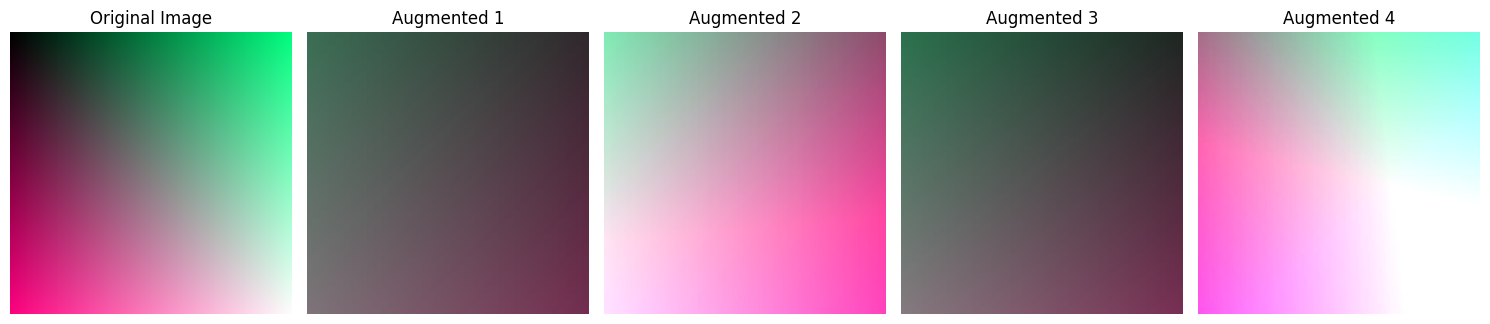

In [20]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# 为了演示，我们创建一个虚拟图像
# 实际应用中，这里会加载真实图像，例如 Image.open(\"path/to/image.jpg\")
def create_dummy_image(width=256, height=256):
    # 创建一个简单的彩色图像，例如渐变色
    img_array = np.zeros((height, width, 3), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            img_array[i, j, 0] = int(255 * (i / height)) # Red channel
            img_array[i, j, 1] = int(255 * (j / width))  # Green channel
            img_array[i, j, 2] = int(255 * ((i + j) / (height + width))) # Blue channel
    return Image.fromarray(img_array)

# 创建一个虚拟图像用于演示
dummy_image = create_dummy_image(300, 300)

# 1. 随机对图像进行裁剪，使其面积比例在 0.08 到 1.0 之间，并将裁剪后的图像缩放到 224x224 像素。
#    使用 transforms.RandomResizedCrop
# 2. 拥有 50% 的概率对图像进行水平翻转。
#    使用 transforms.RandomHorizontalFlip
# 3. 随机改变图像的亮度 (Brightness)、对比度 (Contrast) 和饱和度 (Saturation)，变化范围设为 0.5。
#    使用 transforms.ColorJitter
# 4. 最终将图像转换为 PyTorch 张量 (Tensor)。
#    使用 transforms.ToTensor

# 定义图像增广管道
augmentation_pipeline = transforms.Compose([
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0)), # 1
    transforms.RandomHorizontalFlip(p=0.5), # 2
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5), # 3
    transforms.ToTensor() # 4
])

# 演示增广效果
if __name__ == '__main__':
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    axes[0].imshow(dummy_image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    for i in range(1, 5):
        augmented_tensor = augmentation_pipeline(dummy_image)
        # 将 PyTorch Tensor 转换回 PIL Image 以便显示
        # ToTensor 会将像素值归一化到 [0, 1]，所以需要乘以 255
        augmented_image = transforms.ToPILImage()(augmented_tensor)
        axes[i].imshow(augmented_image)
        axes[i].set_title(f'Augmented {i}')
        axes[i].axis('off')
    
    plt.tight_layout()
    # plt.show()
    plt.savefig('image_augmentation_examples.png')
    print('Image augmentation examples saved as image_augmentation_examples.png')

    # 打印一个增广后的张量信息
    print(f"\nExample augmented tensor shape: {augmented_tensor.shape}")
    print(f"Example augmented tensor dtype: {augmented_tensor.dtype}")
    print(f"Example augmented tensor min value: {augmented_tensor.min()}")
    print(f"Example augmented tensor max value: {augmented_tensor.max()}")




**代码说明**：

1.  **`create_dummy_image` 函数**：为了方便演示，我们创建了一个简单的渐变色图像作为输入。在实际应用中，您会从数据集中加载真实的图像。
2.  **`transforms.Compose`**：这是一个将多个 `transforms` 操作组合在一起的类。它会按顺序将这些操作应用到输入的 PIL Image 上。
3.  **`transforms.RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0))`**：
    *   实现了随机裁剪和缩放。它会从原始图像中随机裁剪一个区域，该区域的面积占原始图像的比例在 `scale` 参数定义的范围内（0.08 到 1.0）。
    *   裁剪后，该区域会被缩放到 `size` 参数指定的大小（224x224 像素）。
    *   这个操作有助于模型学习不同尺度和位置的特征，并对目标在图像中的位置变化具有鲁棒性。
4.  **`transforms.RandomHorizontalFlip(p=0.5)`**：
    *   以 `p=0.5` 的概率（即 50% 的机会）对图像进行水平翻转。
    *   这是一种简单而有效的增广方式，可以帮助模型学习到图像的左右对称性，并减少对特定方向的偏好。
5.  **`transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5)`**：
    *   随机改变图像的亮度、对比度和饱和度。`0.5` 表示这些属性的变化范围是原始值的 $\pm 50\%$。例如，亮度会在 `[1-0.5, 1+0.5]` 即 `[0.5, 1.5]` 之间随机调整。
    *   这个操作可以使模型对图像的光照条件变化具有鲁棒性，提高在不同光照环境下的性能。
6.  **`transforms.ToTensor()`**：
    *   将 PIL Image 或 NumPy `ndarray` 格式的图像转换为 PyTorch `FloatTensor`。
    *   同时，它会将图像的像素值从 `[0, 255]` 范围归一化到 `[0.0, 1.0]` 范围。
    *   此外，它还会调整图像的维度顺序，从 `(H, W, C)` (高度、宽度、通道) 变为 `(C, H, W)` (通道、高度、宽度)，这是 PyTorch 卷积层所期望的输入格式。

通过这个图像增广管道，我们可以在训练过程中动态地生成多样化的训练样本，从而有效地提高模型的泛化能力，使其在面对未见过的数据时表现更佳。

## 6. 目标检测，计算机视觉训练技巧

### 6.1 理论计算题

**问题描述**：
1. 真实框 (Ground Truth) $A = [10, 10, 50, 50]$
2. 预测框 (Prediction Box) $B = [30, 30, 70, 70]$
请计算边界框 $A$ 和边界框 $B$ 之间的 IoU 准确值。

**解答**：

**交并比 (Intersection over Union, IoU)** 是目标检测中常用的一个评估指标，用于衡量真实边界框 (Ground Truth Box) 和预测边界框 (Prediction Box) 之间的重叠程度。IoU 的计算公式为：

$\text{IoU} = \frac{\text{Intersection Area}}{\text{Union Area}}$

其中，Intersection Area 是两个边界框的交集面积，Union Area 是两个边界框的并集面积。

给定两个边界框 $A = [x_{A1}, y_{A1}, x_{A2}, y_{A2}]$ 和 $B = [x_{B1}, y_{B1}, x_{B2}, y_{B2}]$，其中 $(x_1, y_1)$ 是左上角坐标，$(x_2, y_2)$ 是右下角坐标。

*   真实框 $A = [10, 10, 50, 50]$，表示左上角 $(10, 10)$，右下角 $(50, 50)$。
*   预测框 $B = [30, 30, 70, 70]$，表示左上角 $(30, 30)$，右下角 $(70, 70)$。

**步骤 1：计算两个边界框的交集区域**

交集区域的左上角坐标 $(x_{I1}, y_{I1})$ 和右下角坐标 $(x_{I2}, y_{I2})$ 为：

*   $x_{I1} = \text{max}(x_{A1}, x_{B1}) = \text{max}(10, 30) = 30$
*   $y_{I1} = \text{max}(y_{A1}, y_{B1}) = \text{max}(10, 30) = 30$
*   $x_{I2} = \text{min}(x_{A2}, x_{B2}) = \text{min}(50, 70) = 50$
*   $y_{I2} = \text{min}(y_{A2}, y_{B2}) = \text{min}(50, 70) = 50$

交集区域的宽度 $W_I = x_{I2} - x_{I1} = 50 - 30 = 20$
交集区域的高度 $H_I = y_{I2} - y_{I1} = 50 - 30 = 20$

交集面积 $\text{Intersection Area} = W_I \times H_I = 20 \times 20 = 400$

**步骤 2：计算两个边界框的面积**

*   真实框 $A$ 的宽度 $W_A = x_{A2} - x_{A1} = 50 - 10 = 40$
*   真实框 $A$ 的高度 $H_A = y_{A2} - y_{A1} = 50 - 10 = 40$
*   真实框 $A$ 的面积 $\text{Area}_A = W_A \times H_A = 40 \times 40 = 1600$

*   预测框 $B$ 的宽度 $W_B = x_{B2} - x_{B1} = 70 - 30 = 40$
*   预测框 $B$ 的高度 $H_B = y_{B2} - y_{B1} = 70 - 30 = 40$
*   预测框 $B$ 的面积 $\text{Area}_B = W_B \times H_B = 40 \times 40 = 1600$

**步骤 3：计算两个边界框的并集面积**

并集面积 $\text{Union Area} = \text{Area}_A + \text{Area}_B - \text{Intersection Area}$
$\text{Union Area} = 1600 + 1600 - 400 = 3200 - 400 = 2800$

**步骤 4：计算 IoU**

$\text{IoU} = \frac{\text{Intersection Area}}{\text{Union Area}} = \frac{400}{2800} = \frac{1}{7} \approx 0.142857$

所以，边界框 $A$ 和边界框 $B$ 之间的 IoU 准确值约为 **0.1429**。

### 6.2 编程题

**问题描述**：
在计算机视觉训练技巧中，标签平滑 (Label Smoothing) 通过防止模型过于自信地预测某些类别来提高泛化性。标准交叉熵使用独热编码 (One-hot) 作为硬标签。假设 $K$ 分类问题，真实标签对应的目标概率从 1 变为 $1 - \epsilon$，其余错误类别的概率从 0 变为 $\frac{\epsilon}{K-1}$。
请实现一个计算标签平滑后交叉熵损失的函数。

**解答**：

**标签平滑 (Label Smoothing)** 是一种正则化技术，用于防止模型在训练时对标签过于自信，从而提高模型的泛化能力。在传统的独热编码 (One-hot Encoding) 中，真实类别的概率被设置为 1，其他类别的概率被设置为 0。这鼓励模型对真实类别输出极高的概率，对其他类别输出极低的概率，可能导致模型过拟合训练数据。

标签平滑通过将硬标签（One-hot）转换为软标签来解决这个问题。对于一个 $K$ 分类问题，如果真实标签是 $y_{true}$，独热编码的目标概率分布 $p_{hard}$ 为：

$p_{hard}(k) = \begin{cases} 1 & \text{if } k = y_{true} \\ 0 & \text{if } k \neq y_{true} \end{cases}$

标签平滑后的目标概率分布 $p_{soft}$ 为：

$p_{soft}(k) = \begin{cases} 1 - \epsilon & \text{if } k = y_{true} \\ \frac{\epsilon}{K-1} & \text{if } k \neq y_{true} \end{cases}$

其中，$\epsilon$ 是一个小的超参数，通常取 0.1。它表示从真实标签中“窃取”的概率质量，并均匀分配给其他 $K-1$ 个错误类别。

**交叉熵损失函数**：

交叉熵损失的计算公式为：

$L = - \sum_{k=1}^{K} p(k) \log(\hat{p}(k))$

其中 $p(k)$ 是真实的目标概率分布，$\hat{p}(k)$ 是模型预测的概率分布。

我们将实现一个 PyTorch 函数来计算标签平滑后的交叉熵损失。




In [21]:
import torch
import torch.nn.functional as F

def label_smoothed_cross_entropy(logits, target, epsilon, num_classes):
    """
    计算标签平滑后的交叉熵损失。

    参数:
    logits (torch.Tensor): 模型的原始输出 (log-probabilities 之前)。形状为 (batch_size, num_classes)。
    target (torch.Tensor): 真实标签的索引。形状为 (batch_size, )。
    epsilon (float): 标签平滑的超参数。
    num_classes (int): 类别总数。

    返回:
    torch.Tensor: 标签平滑后的交叉熵损失。
    """
    # 将 logits 转换为 log-probabilities
    log_probs = F.log_softmax(logits, dim=-1)

    # 创建独热编码的硬标签
    # target.unsqueeze(-1) 将形状从 (batch_size,) 变为 (batch_size, 1)
    # F.one_hot 期望 target 是 long 类型
    one_hot_target = F.one_hot(target, num_classes=num_classes).float()

    # 计算平滑后的目标概率分布 p_soft
    # (1 - epsilon) * one_hot_target: 真实类别对应的概率
    # epsilon / (num_classes - 1) * (1 - one_hot_target): 错误类别对应的概率
    # (1 - one_hot_target) 是一个掩码，真实类别为 0，错误类别为 1
    smoothed_target = (1 - epsilon) * one_hot_target + epsilon / (num_classes - 1) * (1 - one_hot_target)

    # 计算交叉熵损失
    # - (smoothed_target * log_probs).sum(dim=-1) 是每个样本的损失
    # .mean() 是对所有样本的损失取平均
    loss = -(smoothed_target * log_probs).sum(dim=-1).mean()

    return loss

# 示例使用
if __name__ == '__main__':
    # 假设一个批次有 4 个样本，有 5 个类别
    batch_size = 4
    num_classes = 5
    epsilon = 0.1

    # 模拟模型的原始输出 (logits)
    # 通常是未经激活函数处理的输出
    logits = torch.randn(batch_size, num_classes)
    print('Model Logits:\n', logits)

    # 模拟真实标签 (类别索引)
    target_labels = torch.tensor([0, 2, 1, 4])
    print('True Labels:\n', target_labels)

    # 计算标签平滑后的交叉熵损失
    ls_loss = label_smoothed_cross_entropy(logits, target_labels, epsilon, num_classes)
    print(f'\nLabel Smoothed Cross Entropy Loss (epsilon={epsilon}): {ls_loss.item():.4f}')

    # 对比标准交叉熵损失 (不带标签平滑)
    # F.cross_entropy 内部会进行 log_softmax
    standard_loss = F.cross_entropy(logits, target_labels)
    print(f'Standard Cross Entropy Loss: {standard_loss.item():.4f}')

    # 验证平滑后的目标概率分布
    one_hot_target = F.one_hot(target_labels, num_classes=num_classes).float()
    smoothed_target_dist = (1 - epsilon) * one_hot_target + epsilon / (num_classes - 1) * (1 - one_hot_target)
    print(f'\nSmoothed Target Distribution for first sample:\n', smoothed_target_dist[0])
    print(f'Sum of smoothed target distribution for first sample:\'{smoothed_target_dist[0].sum().item()}')


Model Logits:
 tensor([[ 1.4056,  0.1916,  1.2000,  1.4182,  0.1630],
        [ 0.0974, -0.0782,  0.0076,  1.1408,  0.2859],
        [ 0.5153,  0.1728,  0.5566,  1.8990, -0.2448],
        [ 0.8173, -1.9694, -0.7056, -0.5598, -0.7862]])
True Labels:
 tensor([0, 2, 1, 4])

Label Smoothed Cross Entropy Loss (epsilon=0.1): 1.9168
Standard Cross Entropy Loss: 1.9264

Smoothed Target Distribution for first sample:
 tensor([0.9000, 0.0250, 0.0250, 0.0250, 0.0250])
Sum of smoothed target distribution for first sample:'0.9999998807907104




**代码说明**：

1.  **`label_smoothed_cross_entropy` 函数**：
    *   **`logits`**：模型的原始输出，通常是未经 Softmax 或 LogSoftmax 处理的。
    *   **`target`**：真实标签的类别索引。
    *   **`epsilon`**：标签平滑的强度参数。
    *   **`num_classes`**：总的类别数量。
2.  **`F.log_softmax(logits, dim=-1)`**：将模型的原始输出 `logits` 转换为对数概率 (log-probabilities)。这是计算交叉熵的常用步骤，可以提高数值稳定性。
3.  **`F.one_hot(target, num_classes=num_classes).float()`**：将真实标签 `target` 转换为独热编码形式。例如，如果 `target` 是 `[0, 2]`，`num_classes` 是 3，则 `one_hot_target` 会是 `[[1, 0, 0], [0, 0, 1]]`。
4.  **`smoothed_target = (1 - epsilon) * one_hot_target + epsilon / (num_classes - 1) * (1 - one_hot_target)`**：
    *   这是标签平滑的核心计算。它创建了一个软目标分布 `smoothed_target`。
    *   对于真实类别，其概率从 1 变为 `(1 - epsilon)`。
    *   对于其他错误类别，其概率从 0 变为 `epsilon / (num_classes - 1)`。
    *   `1 - one_hot_target` 创建了一个掩码，其中真实类别位置为 0，其他位置为 1，用于将 `epsilon / (num_classes - 1)` 分配给错误类别。
5.  **`loss = -(smoothed_target * log_probs).sum(dim=-1).mean()`**：
    *   根据交叉熵损失的定义，将平滑后的目标概率 `smoothed_target` 与模型的对数预测概率 `log_probs` 进行逐元素相乘，然后沿类别维度求和 (`sum(dim=-1)`)，得到每个样本的负对数似然。
    *   最后，对所有样本的损失取平均值 (`mean()`)，得到最终的批量损失。

**标签平滑的优点**：

*   **提高泛化能力**：通过鼓励模型不要对训练数据过于自信，标签平滑可以减少过拟合，提高模型在未见过数据上的泛化性能。
*   **提高模型鲁棒性**：它使得模型对训练数据中的噪声标签不那么敏感。
*   **防止过度自信**：在某些情况下，模型可能会以极高的概率预测某个类别，这在实际应用中可能导致不必要的风险。标签平滑可以缓解这种过度自信。

这个函数提供了一个清晰且可运行的标签平滑交叉熵损失的实现，可以方便地集成到 PyTorch 模型的训练流程中。

